# 🚀 Spaceship Titanic - Data Processing

This notebook conducts the preprocessing step to make the dataset more suitable for the defined task.

## Setup & Import Libraries

In [13]:
import pandas as pd
from src import DatasetVisualizer, SpaceShipDataset, MissingValuesAnalyzer

print("Libraries loaded successfully!")

Libraries loaded successfully!


## Load Dataset

In [14]:
dataset_path = 'dataset'

sd = SpaceShipDataset(dataset_path)
sd.print_stats()
sd.train.head(5)

The dataset has been found in 'dataset'!
+====================================================================================================================================================================================================================================+
|                                                                                                     SpaceShip Titanic Dataset                                                                                                      |
+====================================================================================================================================================================================================================================+
| Train Data Size: 8,693 rows                                                                                                                                                                                                        |
| Train Features (20): PassengerId,

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported,Cabin_Deck,Cabin_Num,Cabin_Side,Group_Id,Group_Size,Is_Solo
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False,B,0,P,1,1,True
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True,F,0,S,2,1,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False,A,0,S,3,2,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False,A,0,S,3,2,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True,F,1,S,4,1,True


In [15]:
sd.show_info(split = 'train')


                          🚀 TRAIN DATASET — INFO & STATISTICAL SUMMARY                         
                            Total Rows: 8,693  |  Total Columns: 20                            



                              📋 Feature Overview & Missing Values                              


     Feature   Dtype Non-Null Count Missing Count Missing (%) Unique Values    Sample Value
 PassengerId     str          8,693             0       0.00%         8,693         0001_01
  HomePlanet     str          8,492           201       2.31%             3          Europa
   CryoSleep  object          8,476           217       2.50%             2           False
       Cabin     str          8,494           199       2.29%         6,560           B/0/P
 Destination     str          8,511           182       2.09%             3     TRAPPIST-1e
         Age float64          8,514           179       2.06%            80            39.0
         VIP  object          8,490           203       2.34% 

In [16]:
sd.show_info(split = 'test')


                          🚀 TEST DATASET — INFO & STATISTICAL SUMMARY                          
                            Total Rows: 4,277  |  Total Columns: 19                            



                              📋 Feature Overview & Missing Values                              


     Feature   Dtype Non-Null Count Missing Count Missing (%) Unique Values    Sample Value
 PassengerId     str          4,277             0       0.00%         4,277         0013_01
  HomePlanet     str          4,190            87       2.03%             3           Earth
   CryoSleep  object          4,184            93       2.17%             2            True
       Cabin     str          4,177           100       2.34%         3,265           G/3/S
 Destination     str          4,185            92       2.15%             3     TRAPPIST-1e
         Age float64          4,186            91       2.13%            79            27.0
         VIP  object          4,184            93       2.17% 

## Missing Values Handling

In [17]:
# Initialize the missing values diagnostic analyzer
analyzer = MissingValuesAnalyzer(sd.train)

### Missing Data Overview & Correlation Heatmap

We initialize the `MissingValuesAnalyzer` on the training dataset and compute the pairwise correlation matrix between missingness indicators ($R_i$ and $R_j$). Under **MCAR**, pairwise correlations across all features should be close to $0.00$.

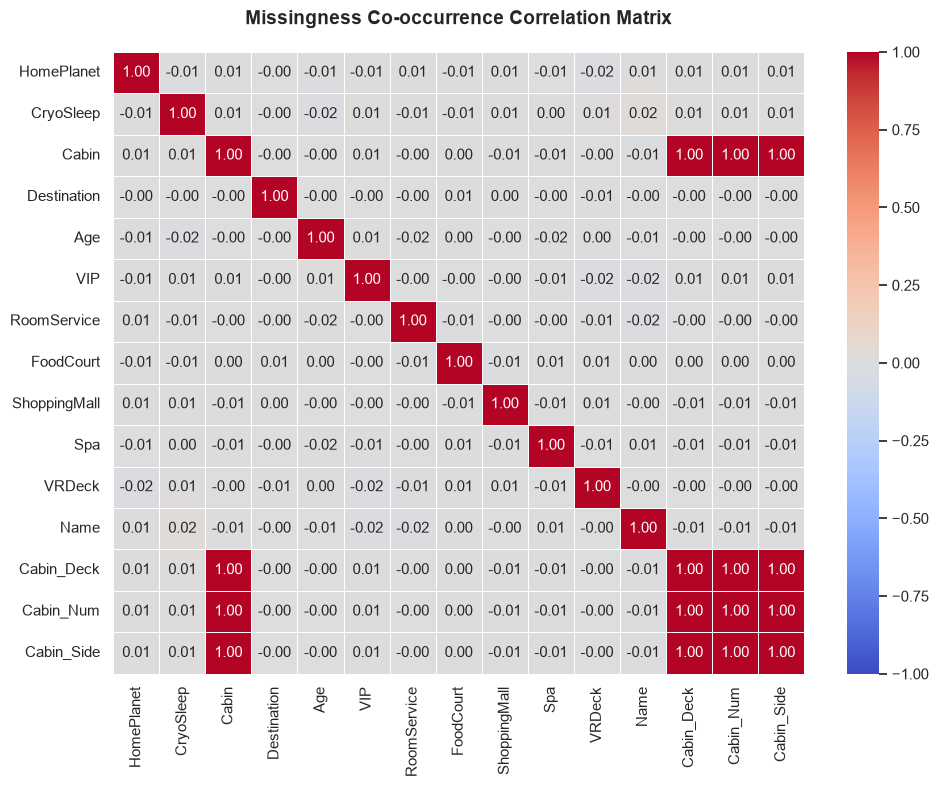

In [18]:
# Visualize missingness co-occurrence correlation matrix
analyzer.plot_missingness_correlation()

### Comprehensive Mechanism Diagnosis Across All Features

We iterate through all the features containing missing values and evaluate:

1. **Statistical Distribution Test (Method 2)**: Welch's two-sample t-test for numeric features and Chi-Square test for categorical features to detect distribution shifts between missing and observed subsets.

2. **Machine Learning Predictability Test (Method 3)**: 5-fold cross-validated ROC-AUC using a Random Forest to determine if missingness can be predicted from other observed features.

*Note: When evaluating a decomposed cabin component (`Cabin_Deck`, `Cabin_Num`, `Cabin_Side`), sibling cabin features are excluded to prevent trivial data leakage.*

In [19]:
missing_cols = ['HomePlanet', 'CryoSleep', 'Destination', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
                'Cabin_Deck', 'Cabin_Side', 'Cabin_Num']

summary_records = []
for col in missing_cols:

    # Exclude sibling cabin features when evaluating a cabin component to prevent trivial leakage
    sibling_excludes = [c for c in ['Cabin_Deck', 'Cabin_Num', 'Cabin_Side', 'Cabin'] if c != col]
    analyzer = MissingValuesAnalyzer(sd.train, exclude_cols = ['PassengerId', 'Name', 'Cabin'] + sibling_excludes)
    
    stat_df = analyzer.test_statistical_differences(col)
    sig_count = int(stat_df['Significant (p < alpha)'].sum()) if not stat_df.empty else 0
    pred = analyzer.test_predictability(col, cv = 5)
    
    summary_records.append({
                                'Feature': col,
                                'Missing Values Count': sd.train[col].isnull().sum(),
                                'Missing Values (%)': round(sd.train[col].isnull().mean() * 100, 2),
                                'Significance Associations': sig_count,
                                'Predictability (ROC-AUC)': pred['mean_roc_auc'],
                                'Mechanism Verdict': 'MCAR' if (sig_count <= 1 and pred['mean_roc_auc'] < 0.58) else 'MAR'
                            })

mechanism_df = pd.DataFrame(summary_records)
mechanism_df

,Feature,Missing Values Count,Missing Values (%),Significance Associations,Predictability (ROC-AUC),Mechanism Verdict
0,HomePlanet,201,2.31,1,0.4803,MCAR
1,CryoSleep,217,2.50,0,0.4797,MCAR
2,Destination,182,2.09,1,0.5443,MCAR
3,Age,179,2.06,2,0.5161,MAR
4,VIP,203,2.34,1,0.5191,MCAR
5,RoomService,181,2.08,0,0.5147,MCAR
6,FoodCourt,183,2.11,1,0.4947,MCAR
7,ShoppingMall,208,2.39,1,0.5401,MCAR
8,Spa,183,2.11,1,0.4988,MCAR
9,VRDeck,188,2.16,3,0.5324,MAR


### Detailed Column-by-Column Diagnoses

Run detailed individual diagnostics on key features to examine exact p-values, feature importances and distribution comparisons.

In [20]:
all_diagnoses = {}

for col in missing_cols:
    sibling_excludes = [c for c in ['Cabin_Deck', 'Cabin_Num', 'Cabin_Side', 'Cabin'] if c != col]
    col_analyzer = MissingValuesAnalyzer(sd.train, exclude_cols = ['PassengerId', 'Name', 'Cabin'] + sibling_excludes)
    all_diagnoses[col] = col_analyzer.diagnose_missing_mechanism(col)

              🧪 MISSING DATA MECHANISM DIAGNOSIS FOR: 'HOMEPLANET'              

[Test 1] Missingness Co-occurrence Correlation:
 - Strongest correlation with: 'VRDeck' (r = -0.018)
 - Result: Co-occurrence correlations are near 0.00 -> Consistent with MCAR.

[Test 2] Statistical Distribution Comparison (alpha = 0.05):
 - Significant features found: 1 out of 13 tested.
 - Result: 1 feature(s) showed statistically significant differences -> Evidence of MAR.

   Top Significant Features:
  Feature         Test  p-value                                               Notes
FoodCourt Welch t-test  0.00022 Mean Missing: 262.64 vs Obs: 462.76 (Diff: -200.12)

[Test 3] Machine Learning Predictability Test:
 - 5-Fold Cross-Validated ROC-AUC: 0.480 (+/- 0.035)
 - Interpretation: Other observed features cannot predict missingness (ROC-AUC ≈ 0.50).

--------------------------------------------------------------------------------
                   🎯 OVERALL VERDICT: MAR (Missing at Random)        

### Imputation Strategy

1. **Uniform MCAR Mechanism**: All features exhibit roughly **2.0% - 2.5%** missingness, with pairwise missingness correlations near **0.00** and predictability ROC-AUC scores hovering around **~0.50**. This confirms missingness is largely **MCAR (Missing Completely at Random)**.

2. **Two-Stage Imputation Strategy**:

   - **Stage 1 (Domain-Logic Imputation)**: Apply deterministic constraints first:

     - If total amenity expenditure $> 0$, passenger cannot be in `CryoSleep` $\rightarrow$ `CryoSleep = False`.

     - If passenger in `CryoSleep == True`, all amenity expenditures must be $0$.
     
     - If `Cabin_Deck` is A, B, C or T $\rightarrow$ `HomePlanet = 'Europa'`.
     
     - If `Cabin_Deck == 'G'` $\rightarrow$ `HomePlanet = 'Earth'`.

   - **Stage 2 (Statistical Imputation)**: For remaining missing values, use group-based medians (e.g., median `Age` by `HomePlanet` + `Cabin_Deck`) or `IterativeImputer` / KNN.

In [ ]:
# We will still have some missing values, but they are related to features we will remove in the next session
sd.handle_missing_values(strategy = 'impute')


Before impute: Train Set Rows: 8,693 | Missing Values: 2,921
            : Test Set Rows:  4,277 | Missing Values: 1,417

After impute: Train Set Rows: 8,693 | Missing Values: 399
            : Test Set Rows:  4,277 | Missing Values: 194


In [22]:
sd.show_info()
sd.show_info('test')


                          🚀 TRAIN DATASET — INFO & STATISTICAL SUMMARY                         
                            Total Rows: 8,693  |  Total Columns: 20                            



                              📋 Feature Overview & Missing Values                              


     Feature   Dtype Non-Null Count Missing Count Missing (%) Unique Values    Sample Value
 PassengerId     str          8,693             0       0.00%         8,693         0001_01
  HomePlanet     str          8,693             0       0.00%             3          Europa
   CryoSleep  object          8,693             0       0.00%             2           False
       Cabin     str          8,494           199       2.29%         6,560           B/0/P
 Destination     str          8,693             0       0.00%             3     TRAPPIST-1e
         Age float64          8,693             0       0.00%           192            39.0
         VIP  object          8,693             0       0.00% 

## High Cardinality Features Handling

The features with an high cardinality do not provide any predictive power and can be safely removed.
In particular:

- **PassegerId** has already been used to derive Group_ID, Group_Size and Is_Solo, so it can be safely removed
- **Cabin** has already been used to derive Cabin_Deck, Cabin_Num and Cabin_Side, so it can be safely removed
- **Name** is not a feature that can suggests whether a person has been trasported or not, we can remove it
- **Group_Id** allowed us to perform imputation for some of the rows but it is now useless for training purposes, we can remove it

In [23]:
sd.drop_high_cardinality_features()

Removed high-cardinality features from train and test sets: PassengerId, Cabin, Name, Group_Id


In [24]:
sd.show_info()
sd.show_info('test')


                          🚀 TRAIN DATASET — INFO & STATISTICAL SUMMARY                         
                            Total Rows: 8,693  |  Total Columns: 16                            



                              📋 Feature Overview & Missing Values                              


     Feature   Dtype Non-Null Count Missing Count Missing (%) Unique Values Sample Value
  HomePlanet     str          8,693             0       0.00%             3       Europa
   CryoSleep  object          8,693             0       0.00%             2        False
 Destination     str          8,693             0       0.00%             3  TRAPPIST-1e
         Age float64          8,693             0       0.00%           192         39.0
         VIP  object          8,693             0       0.00%             2        False
 RoomService float64          8,693             0       0.00%         1,273          0.0
   FoodCourt float64          8,693             0       0.00%         1,507        

## New Feature Introduction

The **RoomService**, **FoodCourt** + **ShoppingMall** + **Spa** + **VRDeck** can be aggregated into a single features that define the total amount of money spent.
We can make a trial to see how each model behaves with this approach and without it.  
Note that we also create another feature, **Has_Spent**, to track whether the passenger has spent some money or not; this feature introduces the multicollinearity problem, so use it only for tree-based models

In [25]:
sd.new_feature_introduction()

Introduced new features: Total_Spending, Has_Spent


In [26]:
sd.show_info()
sd.show_info('test')


                          🚀 TRAIN DATASET — INFO & STATISTICAL SUMMARY                         
                            Total Rows: 8,693  |  Total Columns: 18                            



                              📋 Feature Overview & Missing Values                              


       Feature   Dtype Non-Null Count Missing Count Missing (%) Unique Values Sample Value
    HomePlanet     str          8,693             0       0.00%             3       Europa
     CryoSleep  object          8,693             0       0.00%             2        False
   Destination     str          8,693             0       0.00%             3  TRAPPIST-1e
           Age float64          8,693             0       0.00%           192         39.0
           VIP  object          8,693             0       0.00%             2        False
   RoomService float64          8,693             0       0.00%         1,273          0.0
     FoodCourt float64          8,693             0       0.00%      

## Type Handling

Now we can also define the correct data type for each feature in the dataset

In [27]:
sd.handle_types()

Enforced proper data types across train and test sets:
  - Booleans (bool): CryoSleep, VIP, Transported, Is_Solo, Has_Spent
  - Integers (int64): Age, Cabin_Num, Group_Size
  - Floats (float64): RoomService, FoodCourt, ShoppingMall, Spa, VRDeck, Total_Spending
  - Categoricals (str): HomePlanet, Destination, Cabin_Deck, Cabin_Side


## Feature Scaling and Encoding

In [28]:
sd.scale_and_encode_features()

Feature scaling and encoding complete:
  - Scaled with RobustScaler (9 features): Age, RoomService, FoodCourt, ShoppingMall, Spa, VRDeck, Cabin_Num, Group_Size, Total_Spending
  - One-Hot Encoded (2 features): HomePlanet, Destination
  - Ordinally Encoded (2 features): Cabin_Deck, Cabin_Side
  - Final Train shape: (8693, 22) | Final Test shape: (4277, 21)


## Pre-processed Dataset Result

In [29]:
sd.train.head(5)

,CryoSleep,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,Cabin_Deck,...,Group_Size,Is_Solo,Total_Spending,Has_Spent,HomePlanet_Earth,HomePlanet_Europa,HomePlanet_Mars,Destination_55 Cancri e,Destination_PSO J318.5-22,Destination_TRAPPIST-1e
0,0,0.705882,0,0.000000,0.000000,0.000000,0.000000,0.000000,0,1.0,...,0.0,1,-0.497931,0,0.0,1.0,0.0,0.0,0.0,1.0
1,0,-0.176471,0,2.658537,0.147541,0.806452,10.358491,0.771930,1,5.0,...,0.0,1,0.009655,1,1.0,0.0,0.0,0.0,0.0,1.0
2,0,1.823529,1,1.048780,58.622951,0.000000,126.698113,0.859649,0,0.0,...,0.5,0,6.662759,1,0.0,1.0,0.0,0.0,0.0,1.0
3,0,0.352941,0,0.000000,21.032787,11.967742,62.811321,3.385965,0,0.0,...,0.5,0,3.071724,1,0.0,1.0,0.0,0.0,0.0,1.0
4,0,-0.647059,0,7.390244,1.147541,4.870968,10.660377,0.035088,1,5.0,...,0.0,1,0.254483,1,1.0,0.0,0.0,0.0,0.0,1.0


In [30]:
sd.test.head(5)

,CryoSleep,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Cabin_Deck,Cabin_Num,...,Group_Size,Is_Solo,Total_Spending,Has_Spent,HomePlanet_Earth,HomePlanet_Europa,HomePlanet_Mars,Destination_55 Cancri e,Destination_PSO J318.5-22,Destination_TRAPPIST-1e
0,1,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,6.0,-0.520681,...,0.0,1,-0.497931,0,1.0,0.0,0.0,0.0,0.0,1.0
1,0,-0.470588,0,0.000000,0.147541,0.000000,53.264151,0.000000,5.0,-0.519465,...,0.0,1,1.455172,1,1.0,0.0,0.0,0.0,0.0,1.0
2,1,0.235294,0,0.000000,0.000000,0.000000,0.000000,0.000000,2.0,-0.524331,...,0.0,1,-0.497931,0,0.0,1.0,0.0,1.0,0.0,0.0
3,0,0.647059,0,0.000000,109.049180,0.000000,3.415094,10.263158,2.0,-0.523114,...,0.0,1,4.617931,1,0.0,1.0,0.0,0.0,0.0,1.0
4,0,-0.411765,0,0.243902,0.000000,20.483871,0.000000,0.000000,5.0,-0.518248,...,0.0,1,-0.053103,1,1.0,0.0,0.0,0.0,0.0,1.0
